In [ ]:
# Standard library
import math
import random

# Data manipulation
import numpy as np
import pandas as pd
import geopandas as gpd

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import partial_dependence
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)
from scipy import stats
from sklearn.model_selection import (
    KFold,
)
from sklearn.preprocessing import StandardScaler

# Explainability
import shap

# Custom utilities
import utils.cross_validation as cval

In [14]:
biome_mapping = {
        0: 'Boreal and Tundra forests',
        1: 'Flooded grasslands',
        2: 'Mangroves',
        3: 'Mediterranean woodlands',
        4: 'Temperate broadleaf forests',
        5: 'Temperate conifer forests',
        6: 'Temperate grasslands',
        7: 'Tropical',
        8: 'Tropical',
        9: 'Tropical',
        10: 'Tropical',
        11: 'Boreal and Tundra forests',
        12: 'Xeric shrublands',
        13: np.nan
    }

def train_test_split(df, random_key, test_size):
    sub_df = df.drop(columns=['BHAGE', 'managed',
        'ownership', 'biome', 'geometry', 'index_right', 'lat', 'lon', 'DIA',
        'lon_bin', 'lat_bin', 'TPA_UNADJ', 'WSCI',  'transformed npp', 'mean'])

    sets=list(set(sub_df['ECO_NAME']))
 

    random.seed(random_key)
    test_set = random.sample(sets, int(test_size * len(sets)))
    test = sub_df[sub_df["ECO_NAME"].isin(test_set)]
    train = sub_df[~sub_df["ECO_NAME"].isin(test_set)]

    y=['residuals'] 
    X_train=train.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_train = train['residuals'].values

    X_test= test.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_test = test['residuals'].values
    
    scaler= StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    return X_train, y_train, X_test, y_test


def train_rf_cv(X, y, n_splits=5, rf_params=None):
    if rf_params is None:
        rf_params = {
            'n_estimators': 200,
            'max_depth': None,
            'min_samples_leaf': 2,
            'n_jobs': -1,
            'random_state': 42
        }

    # Fix: reset index to avoid positional/label index mismatch
    X = np.array(X)
    y = np.array(y)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    model = RandomForestRegressor(**rf_params)

    fold_mae, fold_r2 = [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        X_train, X_val = X[train_idx], X[val_idx]  # use .iloc
        y_train, y_val = y[train_idx], y[val_idx]  # use .iloc

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        mae = mean_absolute_error(y_val, y_pred, multioutput='raw_values')
        r2  = r2_score(y_val, y_pred, multioutput='raw_values')

        fold_mae.append(mae)
        fold_r2.append(r2)

        # print(f"Fold {fold} | MAE: {mae.round(3)} | R²: {r2.round(3)}")

    fold_mae = np.array(fold_mae)
    fold_r2  = np.array(fold_r2)

    # print("\n--- Cross-Validation Summary ---")
    # print(f"MAE  — mean: {fold_mae.mean(axis=0).round(3)}, std: {fold_mae.std(axis=0).round(3)}")
    # print(f"R²   — mean: {fold_r2.mean(axis=0).round(3)},  std: {fold_r2.std(axis=0).round(3)}")

    # final_model = RandomForestRegressor(**rf_params)
    # final_model.fit(X, y)
    # print("\nFinal model trained on full dataset.")

    return model, fold_mae, fold_r2

def quick_eval_combined(models_info, figsize_per_plot=(5, 4)):
    type_styles = {
        'Functional Diversity': 'YlOrRd',
        'Species Diversity':    'YlGnBu',
    }

    all_results = []
    for info in models_info:
        y_pred = info['model'].predict(info['X_test'])
        y_test = np.array(info['y_test'])
        y_pred = np.array(y_pred)
        mae    = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
        r2     = r2_score(y_test, y_pred, multioutput='raw_values')
        n_out  = y_test.shape[1] if y_test.ndim > 1 else 1
        all_results.append((info, y_test, y_pred, mae, r2, n_out))

    # Flatten into individual (model, output_index) panels
    panels = []
    for result in all_results:
        info, y_test, y_pred, mae, r2, n_out = result
        for col in range(n_out):
            panels.append((info, y_test, y_pred, mae, r2, col, n_out))

    n_cols = 2
    n_rows = math.ceil(len(panels) / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_rows),
        squeeze=False
    )

    for idx, (info, y_test, y_pred, mae, r2, col, n_out) in enumerate(panels):
        ax    = axes[idx // n_cols, idx % n_cols]
        cmap  = type_styles.get(info['type'], 'Greys')
        label = f"{info['biome']} — {info['type']}"

        y_t = y_test[:, col] if n_out > 1 else y_test
        y_p = y_pred[:, col] if n_out > 1 else y_pred

        hb = ax.hexbin(y_t, y_p, gridsize=40, cmap=cmap, mincnt=1)
        fig.colorbar(hb, ax=ax, label='Count')

        min_val = min(y_t.min(), y_p.min())
        max_val = max(y_t.max(), y_p.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5)

        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'{label}\nOutput {col+1} | MAE: {mae[col]:.3f} | R²: {r2[col]:.3f}')

    # Hide any unused axes
    for idx in range(len(panels), n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].axis('off')

    plt.suptitle('Model Evaluation by Biome & Diversity Type', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

def data_processing_v2(df, biome_mapping):
     
    # df = df[df['biome'].isin([4,5,6,12])]

    df["biome"] = df["biome"].replace(biome_mapping)

    df=cval.assign_spatial_groups(df, grid_size=1.0)

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"  # WGS84
    )

    joined = gpd.sjoin(gdf, ecoregions, how="left", predicate="within")

    biome_dfs = {k: v for k, v in joined.groupby('biome')}
    return biome_dfs

In [15]:

fd_df= pd.read_csv("data/final/fd_df.csv")
sd_df = pd.read_csv("data/final/sd_df.csv")
npp_df1=pd.read_csv('data/processed/npp_volatility.csv')

fd_df = fd_df.merge(npp_df1[['PID','mean']], on='PID')
sd_df = sd_df.merge(npp_df1[['PID','mean']], on='PID')
ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]

fd_df = fd_df.loc[:, ~fd_df.columns.str.contains(r'\.1')]
sd_df = sd_df.loc[:, ~sd_df.columns.str.contains(r'\.1')]

fd_df.drop(columns=['Mean Pairwise D'], inplace=True)
fd_df.dropna(subset=['TPA_UNADJ'], inplace=True) # Maybe exclude

sd_df.dropna(subset=['TPA_UNADJ'], inplace=True) # Maybe exclude
# sd_df = sd_df[sd_df["WSCI"] >= -1000]
# fd_df = fd_df[fd_df["WSCI"] >= -1000]


sd_df.columns = sd_df.columns.str.replace('_x$', '', regex=True)
sd_df.columns = sd_df.columns.str.replace('_y$', '', regex=True)

sd_df = sd_df.loc[:, ~sd_df.columns.duplicated()]

shared_pids = set(sd_df["PID"]).intersection(fd_df["PID"])

# Filter both dataframes to only shared PIDs
sd_df = sd_df[sd_df["PID"].isin(shared_pids)]
fd_df = fd_df[fd_df["PID"].isin(shared_pids)]

#Preprocessing the data for Random forest regression

fbiome_dfs= data_processing_v2(fd_df, biome_mapping)
sbiome_dfs =data_processing_v2(sd_df, biome_mapping)

In [16]:
biomes_list=['Temperate broadleaf forests','Temperate conifer forests',
            'Temperate grasslands', 'Boreal and Tundra forests' ]

Biome: Temperate broadleaf forests
Functional 


/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


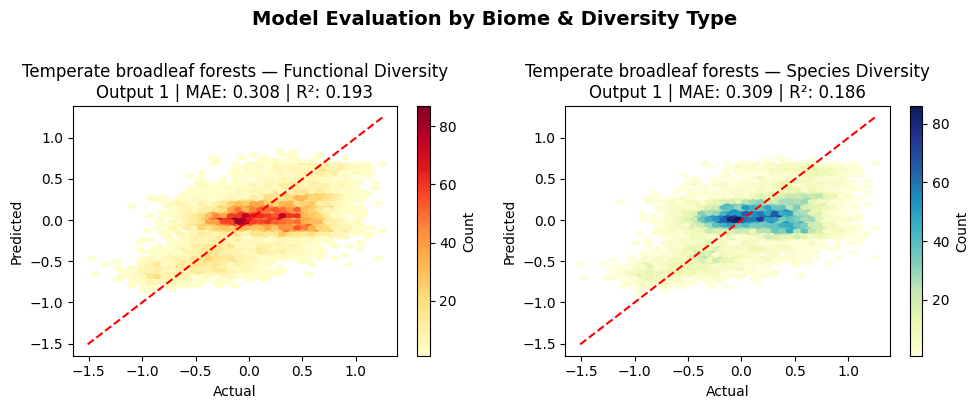

Biome: Temperate conifer forests
Functional 


/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


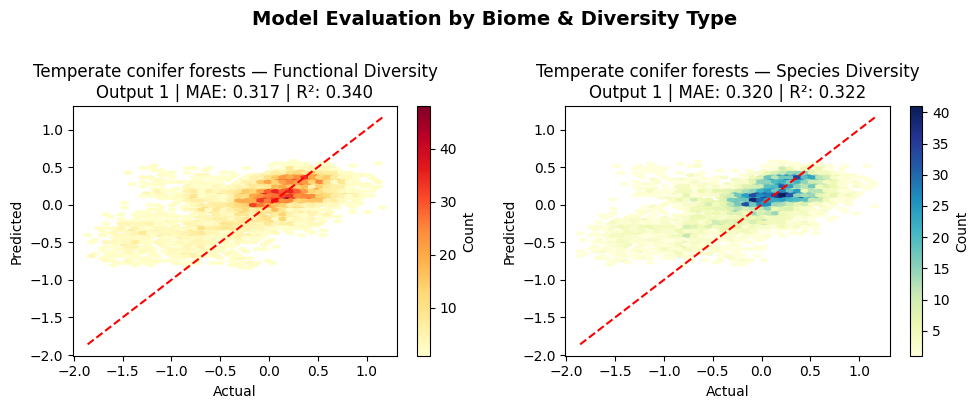

Biome: Temperate grasslands
Functional 


/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


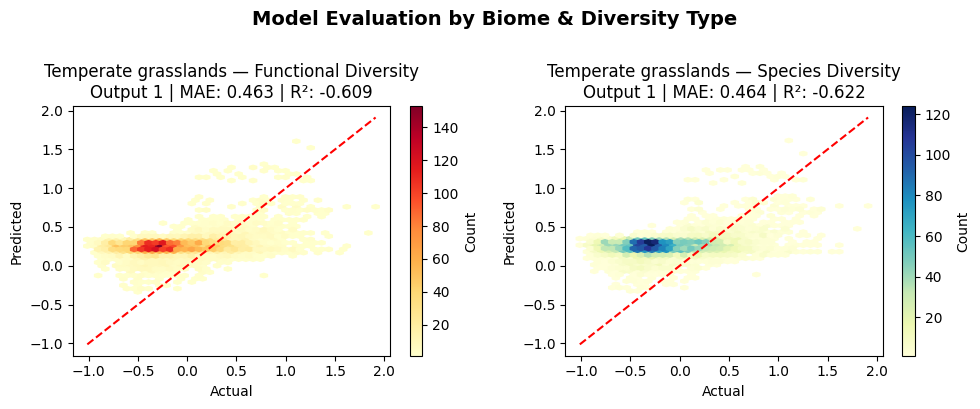

Biome: Boreal and Tundra forests
Functional 


/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


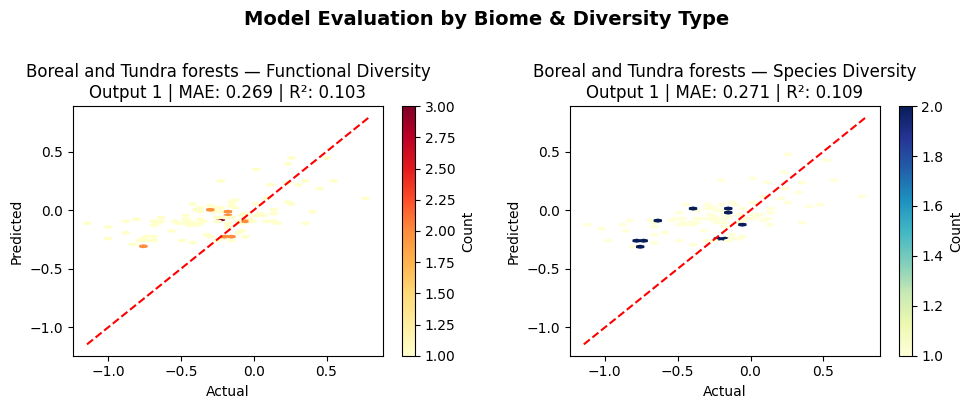

In [20]:
for biome in biomes_list:
    print(f"Biome: {biome}")

    fdf=fbiome_dfs[biome]
    sdf = sbiome_dfs[biome]
    x = fdf['mean'].values
    y = fdf['transformed npp'].values

    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]

    slope, intercept, r, p, se = stats.linregress(x, y)

    y_pred = slope * x + intercept
    residuals = y - y_pred

    fdf['residuals'] = residuals
    sdf['residuals'] = residuals

    
    fX_train, fy_train, fX_test, fy_test = train_test_split(fbiome_dfs[biome], random_key=12, test_size=0.4)
    sX_train, sy_train, sX_test, sy_test = train_test_split(sbiome_dfs[biome], random_key=12, test_size=0.4)
    
    print('Functional ')
    fmodel, mae, r2 = train_rf_cv(fX_train, fy_train, n_splits=10)
    smodel, mae_s, r2_s = train_rf_cv(sX_train, sy_train, n_splits=10)
    models_info = [
    {'model': fmodel, 'X_test': fX_test, 'y_test': fy_test, 'biome': biome, 'type': 'Functional Diversity'},
    {'model': smodel, 'X_test': sX_test, 'y_test': sy_test, 'biome': biome, 'type': 'Species Diversity'},
    ]

    quick_eval_combined(models_info)